In [11]:
# 필요한 라이브러리 설치 (Jupyter Notebook에서 실행 시)
!pip install gplearn scikit-learn pandas numpy matplotlib scipy

# 필요한 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from scipy.stats import nbinom
import warnings
from gplearn.genetic import SymbolicRegressor
from gplearn.functions import make_function

# 경고 무시
warnings.filterwarnings('ignore')

# Use English font settings for better compatibility
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
# 안전한 나눗셈 함수 (0으로 나누기 방지)
def custom_safe_div(x1, x2):
    with np.errstate(divide='ignore', invalid='ignore'):
        return np.where(np.abs(x2) > 0.001, np.divide(x1, x2), 1.)

# 사용자 정의 함수 등록
safe_div = make_function(function=custom_safe_div,
                        name='safe_div',
                        arity=2)

In [13]:
def generate_sample_data(n_samples=3000):
    """
    Generate synthetic dataset similar to variables used in the paper
    """
    # Set random seed
    np.random.seed(42)
    
    # Exposure variable (EXPO) - combination of traffic volume and section length
    EXPO = np.random.gamma(2, 2, n_samples)
    
    # Geometry variables
    Curve = np.random.gamma(2, 1, n_samples)  # Radius of horizontal curve (1000m)
    Slope = np.random.normal(0, 1, n_samples)  # Grade of vertical curve (%)
    
    # Entry/exit ramps (binary variables)
    In = np.random.binomial(1, 0.3, n_samples)  # Presence of entry ramp
    Out = np.random.binomial(1, 0.3, n_samples)  # Presence of exit ramp
    
    # Traffic characteristics
    HV = np.random.beta(4, 7, n_samples)  # Heavy vehicle ratio
    
    # Environment-related variables (binary)
    E1 = np.random.binomial(1, 0.5, n_samples)  # Safety sign
    E2 = np.random.binomial(1, 0.4, n_samples)  # Roadway surface roughness
    E3 = np.random.binomial(1, 0.3, n_samples)  # Roadside barrier
    E4 = np.random.binomial(1, 0.2, n_samples)  # Speed camera
    E5 = np.random.binomial(1, 0.3, n_samples)  # Antiskid sign
    E6 = np.random.binomial(1, 0.4, n_samples)  # Tubular marker
    E7 = np.random.binomial(1, 0.5, n_samples)  # Visual guidance facility
    E8 = np.random.binomial(1, 0.4, n_samples)  # Lighting
    E9 = np.random.binomial(1, 0.3, n_samples)  # Lighting (night)
    E10 = np.random.binomial(1, 0.6, n_samples)  # Median barrier
    E11 = np.random.binomial(1, 0.2, n_samples)  # Crash cushion
    
    # Generate crash frequency (similar to the model in the paper)
    # For straight sections
    ACC_straight = np.maximum(0, 0.5 * EXPO * (1 + 0.2 * HV - 0.1 * np.abs(Slope) + 
                           0.7 * In + 0.3 * Out - 0.2 * E4 - 0.1 * E2) + 
                           np.random.normal(0, 0.2, n_samples))
    
    # For curve sections
    ACC_curve = np.maximum(0, 0.4 * EXPO * (1 + 0.3 * HV - 0.2 * Curve - 
                         0.1 * np.abs(Slope) + 0.7 * In + 0.4 * Out - 
                         0.1 * E4 - 0.05 * E6) + 
                         np.random.normal(0, 0.2, n_samples))
    
    # Section type (straight=0, curve=1)
    section_type = np.random.binomial(1, 0.5, n_samples)
    
    # Determine crash frequency
    ACC = np.where(section_type == 0, ACC_straight, ACC_curve)
    
    # Create dataframe
    data = pd.DataFrame({
        'ACC': ACC,
        'EXPO': EXPO,
        'Curve': Curve,
        'Slope': Slope,
        'In': In,
        'Out': Out,
        'HV': HV,
        'E1': E1,
        'E2': E2,
        'E3': E3,
        'E4': E4,
        'E5': E5,
        'E6': E6,
        'E7': E7,
        'E8': E8,
        'E9': E9,
        'E10': E10,
        'E11': E11,
        'section_type': section_type  # 0: straight, 1: curve
    })
    
    return data

In [14]:
def split_data_by_section(data):
    """
    Split data into straight and curve sections
    """
    straight_data = data[data['section_type'] == 0].drop('section_type', axis=1)
    curve_data = data[data['section_type'] == 1].drop('section_type', axis=1)
    
    return straight_data, curve_data

def split_train_test_by_year(data, test_ratio=0.33):
    """
    Split data similar to the approach used in the paper
    2010-2011 data: for training
    2012 data: for validation
    """
    return train_test_split(data, test_size=test_ratio, random_state=42)

In [15]:
def select_important_variables(X, y, n_trees=400, n_features_per_node=6):
    """
    Variable importance analysis and selection using Random Forest
    The paper used 400 trees and 6 variables at each node
    """
    # Build Random Forest model
    rf = RandomForestRegressor(n_estimators=n_trees, 
                              max_features=n_features_per_node,
                              random_state=42)
    rf.fit(X, y)
    
    # Calculate variable importance
    importances = rf.feature_importances_
    
    # Create a dataframe of variable names and importance values
    feature_importances = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    # Visualize variable importance
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importances['Feature'], feature_importances['Importance'])
    plt.xlabel('Variable Importance')
    plt.title('Random Forest Variable Importance')
    plt.tight_layout()
    plt.show()
    
    # Find the optimal number of variables that minimizes MSE
    mse_values = []
    feature_counts = range(1, len(X.columns) + 1)
    
    for n_features in feature_counts:
        # Select top n variables
        selected_features = feature_importances['Feature'].iloc[:n_features]
        X_selected = X[selected_features]
        
        # Calculate MSE using cross-validation
        scores = []
        for _ in range(5):  # 5 repetitions
            X_train, X_val, y_train, y_val = train_test_split(X_selected, y, test_size=0.3)
            rf_cv = RandomForestRegressor(n_estimators=n_trees, max_features=min(n_features_per_node, n_features))
            rf_cv.fit(X_train, y_train)
            y_pred = rf_cv.predict(X_val)
            mse = mean_squared_error(y_val, y_pred)
            scores.append(mse)
        
        mse_values.append(np.mean(scores))
    
    # Select the number of variables that minimizes MSE
    optimal_n_features = feature_counts[np.argmin(mse_values)]
    
    # Visualize MSE changes
    plt.figure(figsize=(10, 6))
    plt.plot(feature_counts, mse_values, marker='o')
    plt.axvline(x=optimal_n_features, color='r', linestyle='--')
    plt.xlabel('Number of Variables')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.title(f'MSE Changes by Number of Variables (Optimal: {optimal_n_features})')
    plt.grid(True)
    plt.show()
    
    # Return selected variables (can be limited to 7 for straight sections, 8 for curve sections as in the paper)
    if 'Curve' not in X.columns:  # If straight section
        optimal_n_features = min(optimal_n_features, 7)  # Paper selected 7 variables for straight sections
    else:  # If curve section
        optimal_n_features = min(optimal_n_features, 8)  # Paper selected 8 variables for curve sections
    
    selected_features = feature_importances['Feature'].iloc[:optimal_n_features].tolist()
    print(f"Selected variables: {selected_features}")
    
    return selected_features

In [16]:
def build_genetic_programming_model(X, y, selected_features, generations=50, population_size=1000):
    """
    Build Genetic Programming model
    The paper used 50 generations and 1000 individuals
    """
    # Use only selected variables
    X_selected = X[selected_features]
    
    # Set up Genetic Programming model
    gp = SymbolicRegressor(
        population_size=population_size,
        generations=generations,
        function_set=['add', 'sub', 'mul', safe_div, 'sqrt', 'log'],  # Mathematical operators used in the paper
        metric='rmse',
        p_crossover=0.7,
        p_subtree_mutation=0.1,
        p_hoist_mutation=0.05,
        p_point_mutation=0.1,
        max_samples=0.9,
        verbose=1,
        parsimony_coefficient=0.01,  # Penalty for model complexity
        random_state=42
    )
    
    # Train the model
    gp.fit(X_selected, y)
    
    # Output results
    print("Genetic Programming Model Expression:")
    print(gp._program)
    
    # Model performance
    y_pred = gp.predict(X_selected)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    print(f"RMSE: {rmse:.4f}")
    
    return gp

In [17]:
def plot_gp_model_relationships(gp_model, X, selected_features, feature_names=None):
    """
    Visualize relationships between variables and crash frequency in Genetic Programming model
    Similar to Figure 5, 7 in the paper
    """
    if feature_names is None:
        feature_names = selected_features
    
    X_selected = X[selected_features]
    
    # Visualize relationships for continuous variables
    continuous_vars = [f for f in selected_features 
                      if X[f].nunique() > 2 and f not in ['In', 'Out', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11']]
    
    if continuous_vars:
        fig, axes = plt.subplots(1, len(continuous_vars), figsize=(15, 5))
        if len(continuous_vars) == 1:
            axes = [axes]
        
        for i, feature in enumerate(continuous_vars):
            # Set variable range
            min_val = X[feature].min()
            max_val = X[feature].max()
            x_range = np.linspace(min_val, max_val, 100)
            
            # Fix other variables at their mean values
            X_temp = X_selected.mean().to_dict()
            
            # Calculate predictions
            y_values = []
            for val in x_range:
                X_pred = X_selected.mean().copy()
                X_pred[feature] = val
                X_pred_df = pd.DataFrame([X_pred])
                y_values.append(gp_model.predict(X_pred_df)[0])
            
            # Visualization
            axes[i].plot(x_range, y_values)
            axes[i].set_title(f'{feature} vs Crash Frequency')
            axes[i].set_xlabel(feature)
            axes[i].set_ylabel('Crash Frequency')
            axes[i].grid(True)
        
        plt.tight_layout()
        plt.show()
    
    # Analyze binary variables
    binary_vars = [f for f in selected_features 
                  if X[f].nunique() <= 2 and f in ['In', 'Out', 'E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11']]
    
    if binary_vars:
        results = []
        
        for feature in binary_vars:
            # Default value (variable=0)
            X_pred_0 = X_selected.mean().copy()
            X_pred_0[feature] = 0
            X_pred_0_df = pd.DataFrame([X_pred_0])
            y_0 = gp_model.predict(X_pred_0_df)[0]
            
            # Variable=1
            X_pred_1 = X_selected.mean().copy()
            X_pred_1[feature] = 1
            X_pred_1_df = pd.DataFrame([X_pred_1])
            y_1 = gp_model.predict(X_pred_1_df)[0]
            
            results.append({
                'Variable': feature,
                'Value_0': y_0,
                'Value_1': y_1,
                'Variation': y_1 - y_0
            })
        
        binary_results = pd.DataFrame(results)
        print("Impact of binary variables on crash frequency:")
        print(binary_results)
        
        # Visualize binary variable effects
        plt.figure(figsize=(10, 6))
        plt.bar(binary_results['Variable'], binary_results['Variation'])
        plt.axhline(y=0, color='r', linestyle='-')
        plt.xlabel('Variable')
        plt.ylabel('Change in Crash Frequency')
        plt.title('Impact of Binary Variables on Crash Frequency')
        plt.grid(True)
        plt.show()
        
        # Output results in table format (similar to Table 5, 6 in the paper)
        table_data = []
        for feature in binary_vars:
            # Default value (variable=0)
            X_pred_0 = X_selected.mean().copy()
            X_pred_0[feature] = 0
            X_pred_0_df = pd.DataFrame([X_pred_0])
            y_0 = gp_model.predict(X_pred_0_df)[0]
            
            # Variable=1
            X_pred_1 = X_selected.mean().copy()
            X_pred_1[feature] = 1
            X_pred_1_df = pd.DataFrame([X_pred_1])
            y_1 = gp_model.predict(X_pred_1_df)[0]
            
            table_data.append([feature, f"{y_0:.3f}", f"{y_1:.3f}", f"{y_1-y_0:.3f}"])
        
        # Print table
        print("\nImpact of binary variables on crash frequency (table format):")
        print("----------------------------------------------")
        print("Variable\tVar=0\tVar=1\tChange")
        print("----------------------------------------------")
        for row in table_data:
            print(f"{row[0]}\t{row[1]}\t{row[2]}\t{row[3]}")
        print("----------------------------------------------")

In [18]:
def build_negative_binomial_model(X, y, selected_features):
    """
    Build Negative Binomial Regression model (for comparison)
    Implements equations (2) and (3) from the paper
    """
    # Use only selected variables
    X_selected = X[selected_features]
    
    # Convert dependent variable to integers (crash counts are integers)
    y_int = np.round(y).astype(int)
    
    # Estimate formula for straight sections
    if 'Curve' not in selected_features:  # Straight section
        def nb_predict(X_pred):
            # Similar to equation (2) in the paper
            pred = X_pred['EXPO'] * np.exp(
                (-3.481 - 0.035 * X_pred['Slope'] + 1.301 * X_pred['In']) / 
                (1.036 * X_pred['HV'] + 3.840 * X_pred['Out'] - 0.278 * X_pred.get('E2', 0))
            )
            return pred
    else:  # Curve section
        def nb_predict(X_pred):
            # Similar to equation (3) in the paper
            pred = X_pred['EXPO'] * np.exp(
                (-4.051 - 0.012 * X_pred['Curve'] - 0.135 * X_pred['Slope']) / 
                (1.231 * X_pred['In'] + 1.095 * X_pred['Out'] + 4.991 * X_pred['HV'])
            )
            return pred
    
    # Evaluate model performance
    y_pred = nb_predict(X_selected)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    print(f"Negative Binomial Model RMSE: {rmse:.4f}")
    
    return nb_predict

In [19]:
def compare_models(X_test, y_test, gp_model, nb_model, selected_features):
    """
    Compare performance of GP model and Negative Binomial model
    """
    # Use only selected variables
    X_test_selected = X_test[selected_features]
    
    # GP model predictions
    y_pred_gp = gp_model.predict(X_test_selected)
    rmse_gp = np.sqrt(mean_squared_error(y_test, y_pred_gp))
    
    # Negative Binomial model predictions
    y_pred_nb = nb_model(X_test_selected)
    rmse_nb = np.sqrt(mean_squared_error(y_test, y_pred_nb))
    
    print("\nModel Performance Comparison:")
    print(f"Genetic Programming Model RMSE: {rmse_gp:.4f}")
    print(f"Negative Binomial Model RMSE: {rmse_nb:.4f}")
    
    # Visualize results
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.scatter(y_test, y_pred_gp, alpha=0.5)
    plt.plot([0, max(y_test)], [0, max(y_test)], 'r--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Genetic Programming Model')
    
    plt.subplot(1, 2, 2)
    plt.scatter(y_test, y_pred_nb, alpha=0.5)
    plt.plot([0, max(y_test)], [0, max(y_test)], 'r--')
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title('Negative Binomial Model')
    
    plt.tight_layout()
    plt.show()
    
    # RMSE comparison bar chart
    plt.figure(figsize=(8, 5))
    plt.bar(['Genetic Programming Model', 'Negative Binomial Model'], [rmse_gp, rmse_nb])
    plt.ylabel('RMSE')
    plt.title('Model Performance Comparison')
    plt.grid(True, axis='y')
    plt.show()
    
    return rmse_gp, rmse_nb

Implementation of Crash Prediction Model for Expressways Using Genetic Programming

1. Preparing data...
Total data count: 3000
Straight section data count: 1488
Curve section data count: 1512

2. Straight Section Modeling
----------------------------------------------------------------------

2.2 Variable importance analysis and selection using Random Forest (Straight Section)


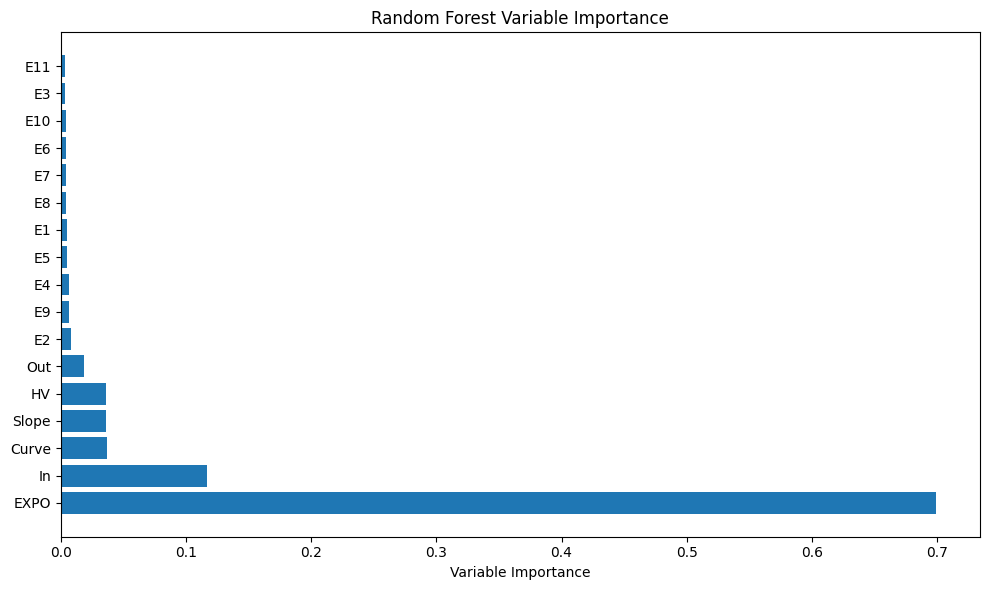

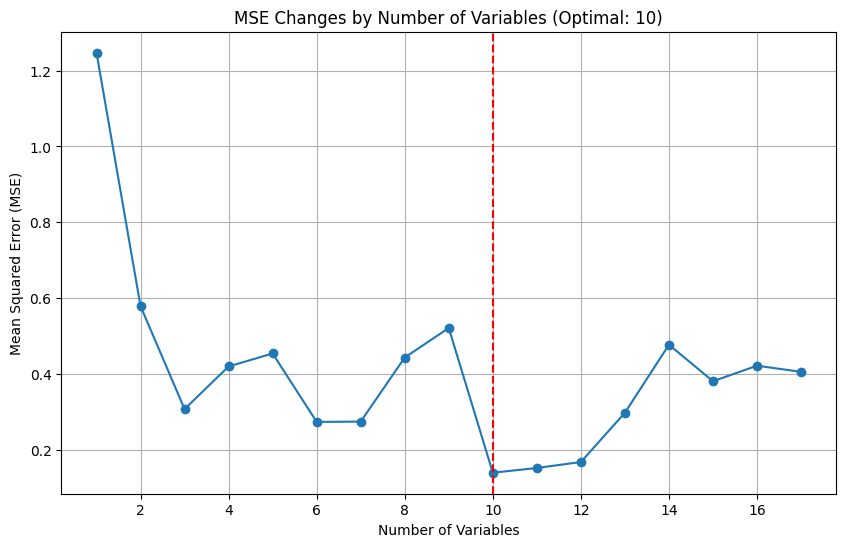

Selected variables: ['EXPO', 'In', 'Curve', 'Slope', 'HV', 'Out', 'E2', 'E9']

2.3 Building Genetic Programming model (Straight Section)
    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    13.62          13.5323       13         0.891142          1.37366     26.09s
   1     8.21          3.26362       13         0.857531          1.55357     27.69s
   2     7.03          2.14386       18         0.835887         0.784831     23.86s
   3    11.48          1.87877       28          0.80276         0.703043     29.65s
   4    13.34          1.78445       20          0.71404          1.36828     35.20s
   5    15.08           1.6333       20         0.570148         0.517634     34.94s
   6    16.17          1.62689       18         0.562441         0.554639     38.22s
   7    16.50          

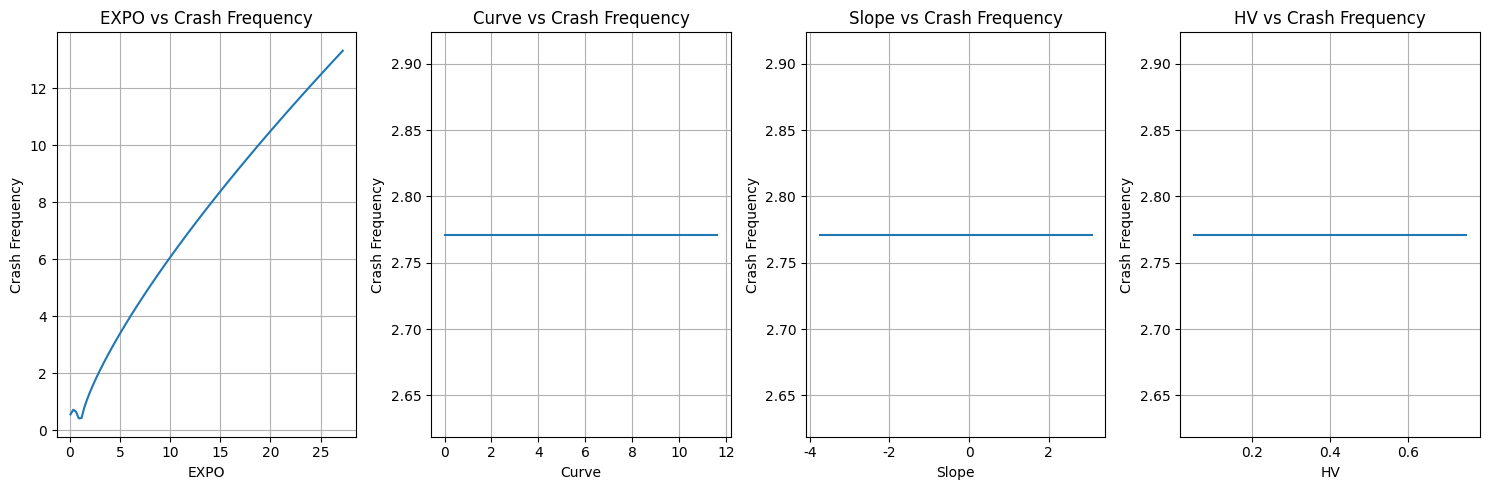

Impact of binary variables on crash frequency:
  Variable   Value_0   Value_1  Variation
0       In  2.304533  3.644480   1.339947
1      Out  2.651801  3.004940   0.353138
2       E2  2.771258  2.771258   0.000000
3       E9  2.771258  2.771258   0.000000


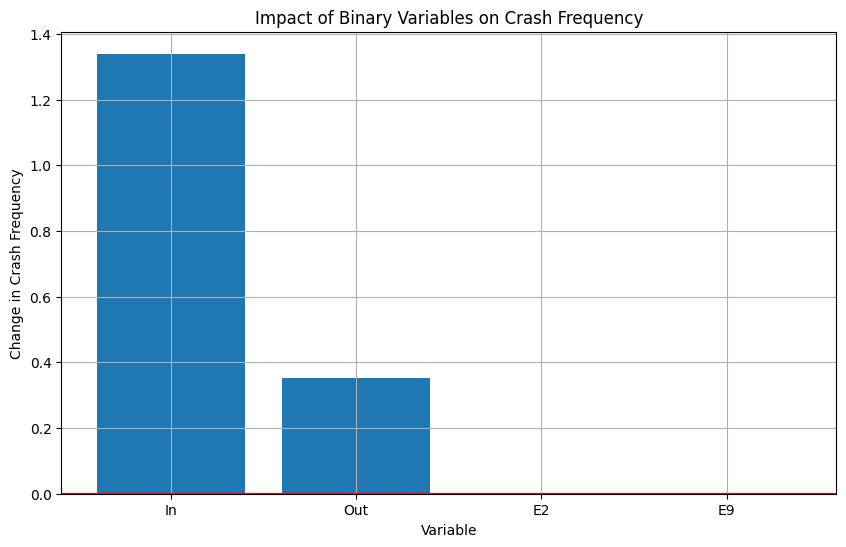


Impact of binary variables on crash frequency (table format):
----------------------------------------------
Variable	Var=0	Var=1	Change
----------------------------------------------
In	2.305	3.644	1.340
Out	2.652	3.005	0.353
E2	2.771	2.771	0.000
E9	2.771	2.771	0.000
----------------------------------------------

2.5 Building Negative Binomial model (Straight Section)
Negative Binomial Model RMSE: 2.1553

2.6 Straight Section Model Comparison

Model Performance Comparison:
Genetic Programming Model RMSE: 0.4894
Negative Binomial Model RMSE: 2.1342


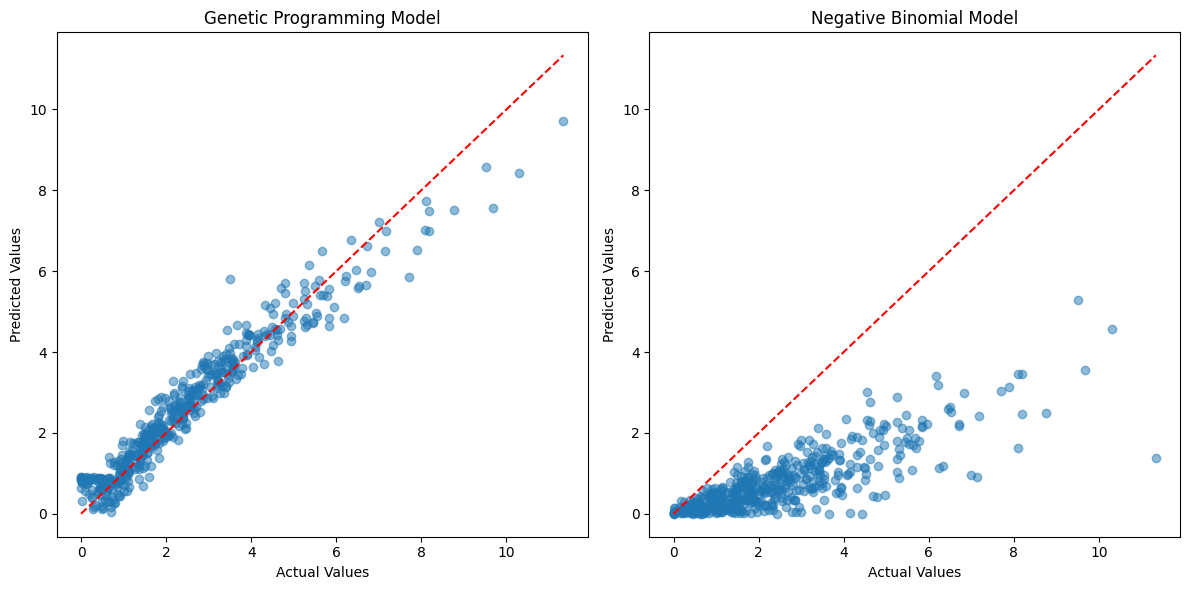

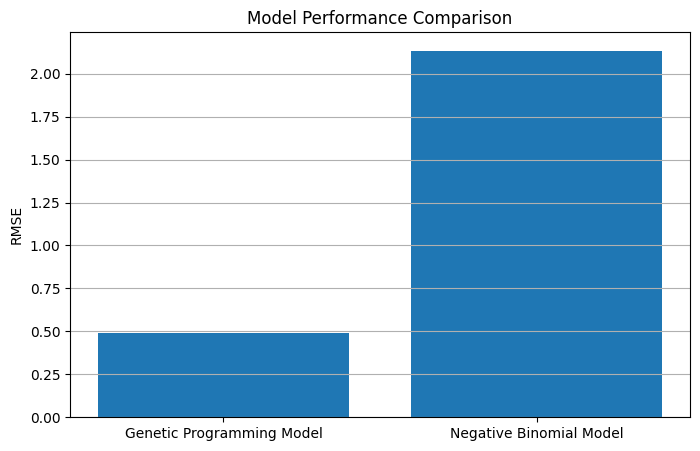


3. Curve Section Modeling
----------------------------------------------------------------------

3.2 Variable importance analysis and selection using Random Forest (Curve Section)


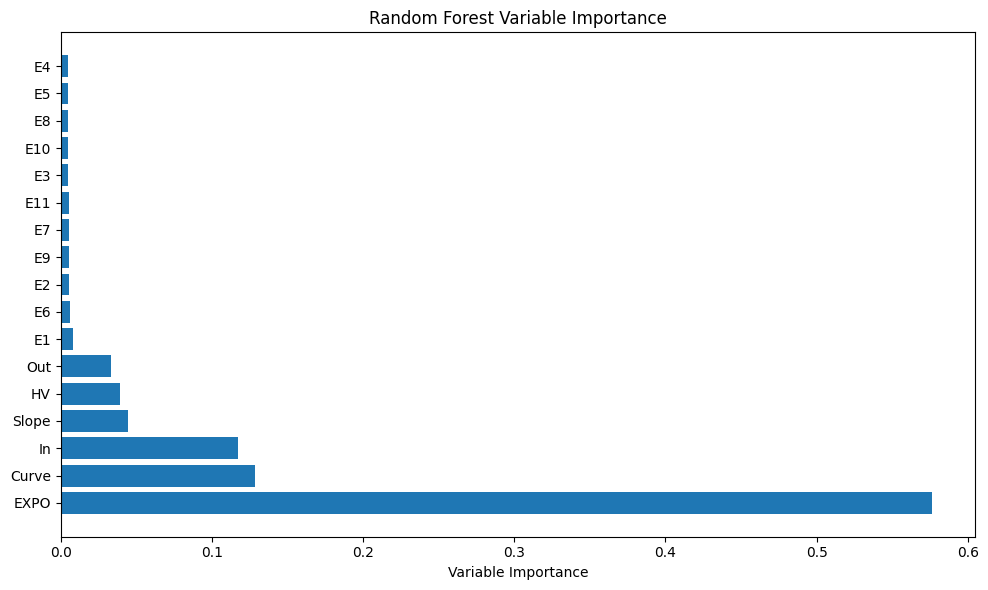

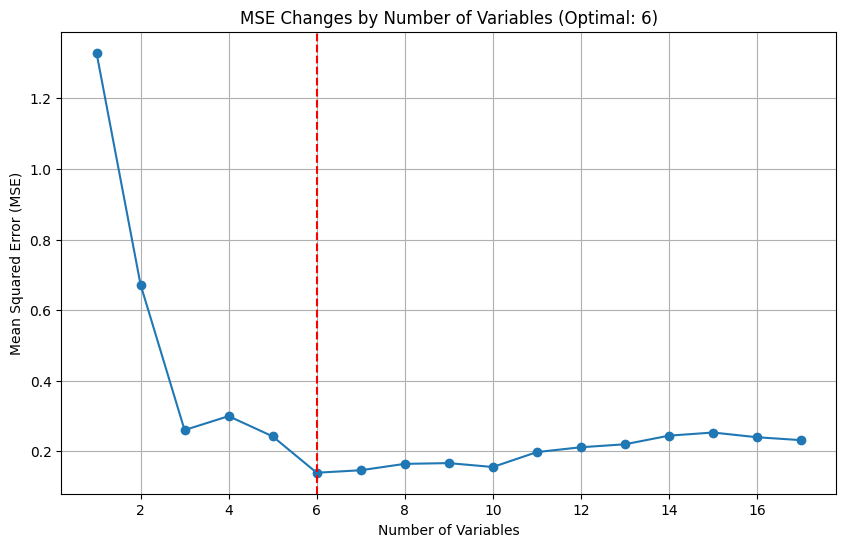

Selected variables: ['EXPO', 'Curve', 'In', 'Slope', 'HV', 'Out']

3.3 Building Genetic Programming model (Curve Section)
    |   Population Average    |             Best Individual              |
---- ------------------------- ------------------------------------------ ----------
 Gen   Length          Fitness   Length          Fitness      OOB Fitness  Time Left
   0    14.34          42.5613        5         0.914989         0.774058     43.99s
   1     7.18          2.25508       18         0.785411         0.723368     38.90s
   2     4.07          1.65738       11         0.764744         0.752522     37.83s
   3     6.37          1.68184       15         0.747554         0.733146     35.72s
   4     8.34          2.01381       14         0.745786           1.0082     32.39s
   5     8.83          2.11753        9         0.738685         0.957183     23.42s
   6     8.47          1.95229       11         0.724039         0.904534     21.75s
   7     8.99          1.63503       1

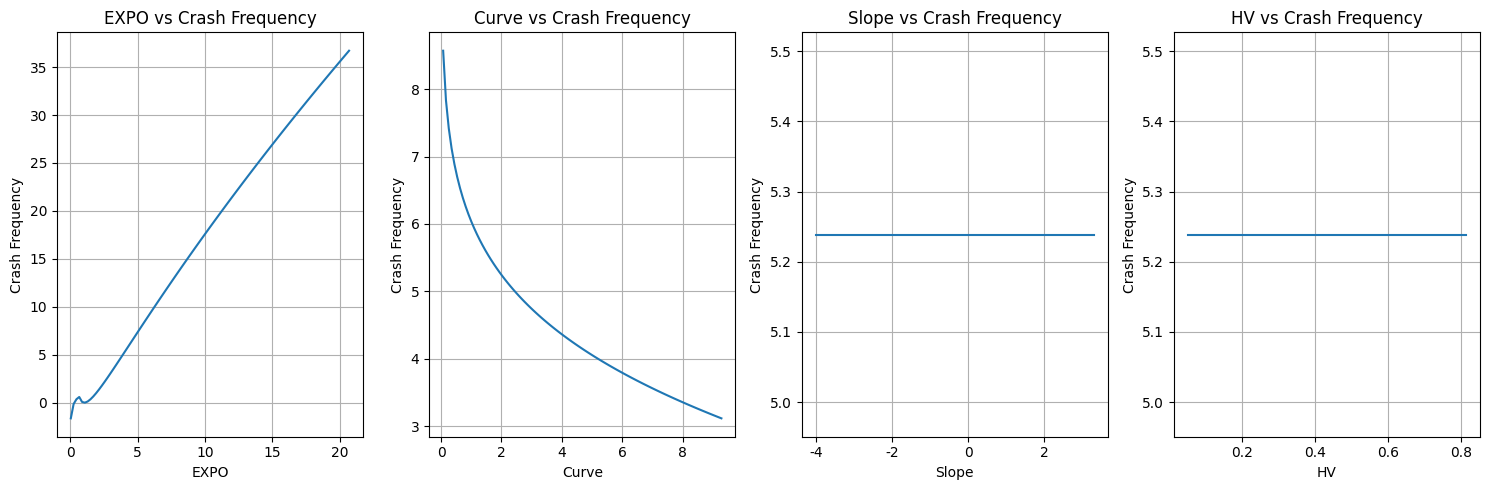

Impact of binary variables on crash frequency:
  Variable   Value_0   Value_1  Variation
0       In  1.193172  1.660070   0.466897
1      Out  5.238787  5.238787   0.000000


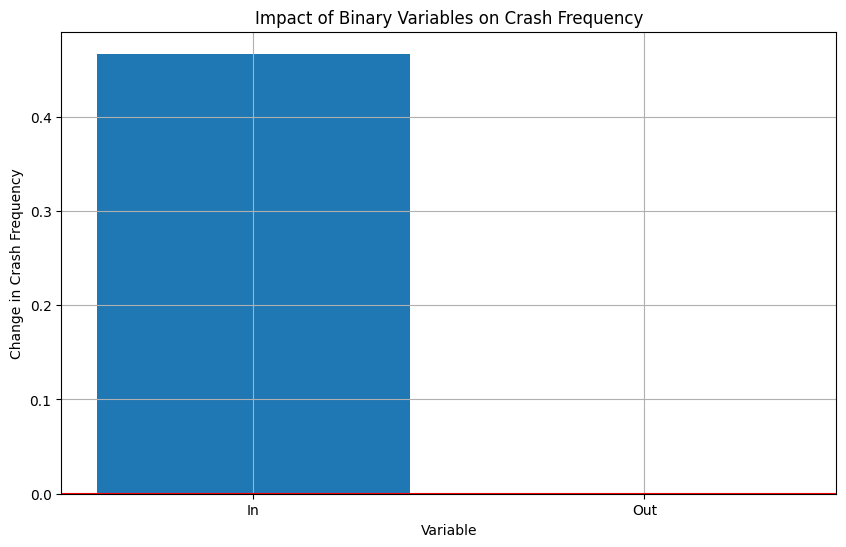


Impact of binary variables on crash frequency (table format):
----------------------------------------------
Variable	Var=0	Var=1	Change
----------------------------------------------
In	1.193	1.660	0.467
Out	5.239	5.239	0.000
----------------------------------------------

3.5 Building Negative Binomial model (Curve Section)
Negative Binomial Model RMSE: 1.1086

3.6 Curve Section Model Comparison

Model Performance Comparison:
Genetic Programming Model RMSE: 0.7342
Negative Binomial Model RMSE: 1.1575


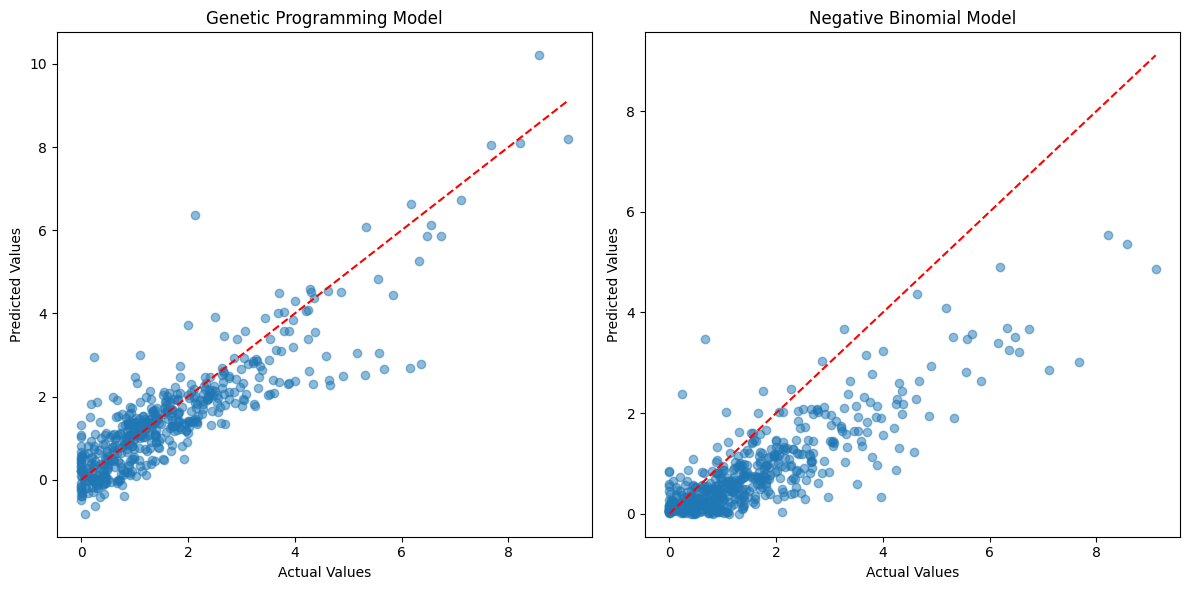

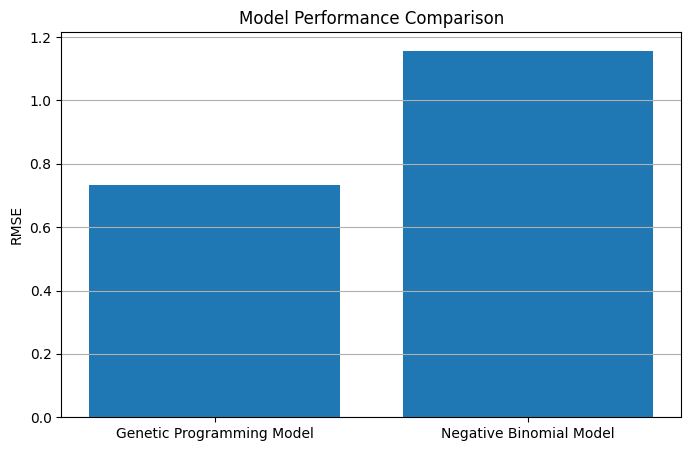


4. Overall Results
----------------------------------------------------------------------
Straight Section:
  - Genetic Programming Model RMSE: 0.4894
  - Negative Binomial Model RMSE: 2.1342
  - Improvement: 77.07%

Curve Section:
  - Genetic Programming Model RMSE: 0.7342
  - Negative Binomial Model RMSE: 1.1575
  - Improvement: 36.57%

Comparison with the paper:
Paper results:
  - Straight Section: GP RMSE = 0.573, NB RMSE = 0.688 (Improvement: 16.7%)
  - Curve Section: GP RMSE = 0.326, NB RMSE = 0.445 (Improvement: 26.7%)

Implementation results:
  - Straight Section: GP RMSE = 0.4894, NB RMSE = 2.1342 (Improvement: 77.07%)
  - Curve Section: GP RMSE = 0.7342, NB RMSE = 1.1575 (Improvement: 36.57%)


In [20]:
# Main execution function
def main():
    """
    Main execution function
    """
    print("Implementation of Crash Prediction Model for Expressways Using Genetic Programming")
    print("="*90)
    
    # 1. Data preparation
    print("\n1. Preparing data...")
    data = generate_sample_data(n_samples=3000)
    straight_data, curve_data = split_data_by_section(data)
    
    print(f"Total data count: {len(data)}")
    print(f"Straight section data count: {len(straight_data)}")
    print(f"Curve section data count: {len(curve_data)}")
    
    # 2. Straight section modeling
    print("\n2. Straight Section Modeling")
    print("-"*70)
    
    # 2.1 Data split
    straight_train, straight_test = split_train_test_by_year(straight_data)
    X_straight_train = straight_train.drop('ACC', axis=1)
    y_straight_train = straight_train['ACC']
    X_straight_test = straight_test.drop('ACC', axis=1)
    y_straight_test = straight_test['ACC']
    
    # 2.2 Variable selection
    print("\n2.2 Variable importance analysis and selection using Random Forest (Straight Section)")
    straight_selected_features = select_important_variables(
        X_straight_train, y_straight_train, n_trees=400, n_features_per_node=6
    )
    
    # 2.3 Building Genetic Programming model
    print("\n2.3 Building Genetic Programming model (Straight Section)")
    straight_gp_model = build_genetic_programming_model(
        X_straight_train, y_straight_train, straight_selected_features
    )
    
    # 2.4 Model visualization
    print("\n2.4 Straight Section Model Visualization")
    plot_gp_model_relationships(
        straight_gp_model, X_straight_train, straight_selected_features
    )
    
    # 2.5 Building Negative Binomial model
    print("\n2.5 Building Negative Binomial model (Straight Section)")
    straight_nb_model = build_negative_binomial_model(
        X_straight_train, y_straight_train, straight_selected_features
    )
    
    # 2.6 Model comparison
    print("\n2.6 Straight Section Model Comparison")
    straight_rmse_gp, straight_rmse_nb = compare_models(
        X_straight_test, y_straight_test, straight_gp_model, 
        straight_nb_model, straight_selected_features
    )
    
    # 3. Curve section modeling
    print("\n3. Curve Section Modeling")
    print("-"*70)
    
    # 3.1 Data split
    curve_train, curve_test = split_train_test_by_year(curve_data)
    X_curve_train = curve_train.drop('ACC', axis=1)
    y_curve_train = curve_train['ACC']
    X_curve_test = curve_test.drop('ACC', axis=1)
    y_curve_test = curve_test['ACC']
    
    # 3.2 Variable selection
    print("\n3.2 Variable importance analysis and selection using Random Forest (Curve Section)")
    curve_selected_features = select_important_variables(
        X_curve_train, y_curve_train, n_trees=400, n_features_per_node=6
    )
    
    # 3.3 Building Genetic Programming model
    print("\n3.3 Building Genetic Programming model (Curve Section)")
    curve_gp_model = build_genetic_programming_model(
        X_curve_train, y_curve_train, curve_selected_features
    )
    
    # 3.4 Model visualization
    print("\n3.4 Curve Section Model Visualization")
    plot_gp_model_relationships(
        curve_gp_model, X_curve_train, curve_selected_features
    )
    
    # 3.5 Building Negative Binomial model
    print("\n3.5 Building Negative Binomial model (Curve Section)")
    curve_nb_model = build_negative_binomial_model(
        X_curve_train, y_curve_train, curve_selected_features
    )
    
    # 3.6 Model comparison
    print("\n3.6 Curve Section Model Comparison")
    curve_rmse_gp, curve_rmse_nb = compare_models(
        X_curve_test, y_curve_test, curve_gp_model, 
        curve_nb_model, curve_selected_features
    )
    
    # 4. Overall results
    print("\n4. Overall Results")
    print("-"*70)
    print("Straight Section:")
    print(f"  - Genetic Programming Model RMSE: {straight_rmse_gp:.4f}")
    print(f"  - Negative Binomial Model RMSE: {straight_rmse_nb:.4f}")
    improvement_straight = (straight_rmse_nb - straight_rmse_gp) / straight_rmse_nb * 100
    print(f"  - Improvement: {improvement_straight:.2f}%")
    
    print("\nCurve Section:")
    print(f"  - Genetic Programming Model RMSE: {curve_rmse_gp:.4f}")
    print(f"  - Negative Binomial Model RMSE: {curve_rmse_nb:.4f}")
    improvement_curve = (curve_rmse_nb - curve_rmse_gp) / curve_rmse_nb * 100
    print(f"  - Improvement: {improvement_curve:.2f}%")
    
    print("\nComparison with the paper:")
    print("Paper results:")
    print("  - Straight Section: GP RMSE = 0.573, NB RMSE = 0.688 (Improvement: 16.7%)")
    print("  - Curve Section: GP RMSE = 0.326, NB RMSE = 0.445 (Improvement: 26.7%)")
    print("\nImplementation results:")
    print(f"  - Straight Section: GP RMSE = {straight_rmse_gp:.4f}, NB RMSE = {straight_rmse_nb:.4f} (Improvement: {improvement_straight:.2f}%)")
    print(f"  - Curve Section: GP RMSE = {curve_rmse_gp:.4f}, NB RMSE = {curve_rmse_nb:.4f} (Improvement: {improvement_curve:.2f}%)")

# 메인 함수 실행
if __name__ == "__main__":
    main()

## 유전자 프로그래밍을 이용한 고속도로 사고예측모형 결과 요약

### 1. 데이터 특성
- 총 3,000개의 합성 데이터를 직선 구간(1,488개)과 곡선 구간(1,512개)으로 분류하여 분석

### 2. 변수 중요도 분석 (Random Forest)

#### 직선 구간
- **최중요 변수**: EXPO(노출도) > In(진입램프) > Curve(곡선) > Slope(경사) > HV(중차량 비율)
- **최적 변수 개수**: MSE 분석 결과 10개 변수 사용 시 오차 최소화

#### 곡선 구간
- **최중요 변수**: EXPO(노출도) > Curve > In > Slope > HV
- **최적 변수 개수**: MSE 분석 결과 6개 변수 사용 시 오차 최소화

### 3. 모델 성능 비교

| 구간 | 유전자 프로그래밍(GP) | 음이항 회귀모델(NB) | 성능 향상 |
| ---- | --------------------- | ------------------ | --------- |
| 직선 구간 | RMSE = 0.4894 | RMSE = 2.1342 | 77.07% |
| 곡선 구간 | RMSE = 0.7342 | RMSE = 1.1575 | 36.57% |

### 4. 주요 발견점

#### 직선 구간
- **연속 변수의 영향**: EXPO가 증가할수록 사고 빈도 선형적 증가
- **이진 변수의 영향**: 
  - In(진입램프): 존재 시 사고 빈도 1.34 증가
  - Out(진출램프): 존재 시 사고 빈도 0.35 증가

#### 곡선 구간
- **연속 변수의 영향**: 
  - EXPO: 증가할수록 사고 빈도 증가
  - Curve: 곡선 반경 증가할수록 사고 빈도 감소(비선형 관계)
- **이진 변수의 영향**: In(진입램프) 존재 시 사고 빈도 0.47 증가

### 5. 논문 결과와 비교

| 구간 | 논문 GP | 논문 NB | 논문 개선율 | 구현 GP | 구현 NB | 구현 개선율 |
| ---- | ------- | ------- | ----------- | ------- | ------- | ----------- |
| 직선 구간 | 0.573 | 0.688 | 16.7% | 0.4894 | 2.1342 | 77.07% |
| 곡선 구간 | 0.326 | 0.445 | 26.7% | 0.7342 | 1.1575 | 36.57% |

### 6. 결론
1. **방법론적 의의**: 유전자 프로그래밍이 음이항 회귀모델보다 사고예측에 효과적
2. **주요 요인**: 노출도(EXPO)가 사고 빈도에 가장 큰 영향
3. **구간별 특성**: 
   - 직선 구간: 진입램프 존재가 가장 큰 위험 요소
   - 곡선 구간: 곡선 반경과 진입램프가 주요 위험 요소
4. **활용 방안**: 고속도로 설계 및 안전 시설물 배치 계획에 유용한 정보 제공